### Анализ результатов A/B-теста

#### Задание

В рамках проекта выступала в роли аналитика дейтингового приложения.

Помимо базовых функций, в приложении имеется премиум-подписка, которая дает доступ к дополнительным возможностям. В рамках A/B-теста для новых пользователей из нескольких стран была изменена стоимость премиум-подписки при покупке через две новые платежные системы. Стоимость пробного периода при этом оставалась прежней.

**Цель исследования:** определить, был ли эксперимент успешен в целом.

В эксперименте участвовали три группы:
- `test` — тестовая группа;
- `control_1` — первая контрольная группа;
- `control_2` — вторая контрольная группа.

#### Данные

Для анализа предоставлены два типа данных:

**users_*.csv** — информация о пользователях:
- uid – идентификатор пользователя
- age – возраст
- attraction_coeff – коэффициент привлекательности (от 0 до 1000, (лайки/просмотры)*1000 )
- coins – число монеток (внутренняя валюта)
- country – страна  
- visit_days – в какие дни после регистрации пользователь посещал приложение
- gender – пол
- age_filter_start  – фильтр поиска, мин. значение 
- age_filter_end  – фильтр поиска, макс. значение 
- views_count – число полученных оценок 
- was_premium – был ли когда-либо премиум (либо пробный период премиум-статуса, либо купленный за деньги)
- is_premium –  является ли премиум
- total_revenue – нормированная выручка 

**transactions_*.csv** — информация о платежах:
- uid – идентификатор пользователя
- country – страна
- joined_at – дата и время регистрации
- paid_at – дата и время покупки
- revenue – нормированная выручка
- payment_id – идентификатор платежа
- from_page – откуда пользователь перешел на страницу оплаты
- product_type – тип продукта (trial_premium – пробная премиум-подписка, premium_no_trial – премиум-подписка без пробной, coins – подписка за внутреннюю валюту, other_type – другое) 

#### Задача

Проверить, был ли эксперимент успешен, и оценить влияние изменения стоимости премиум-подписки на ключевые продуктовые метрики.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

from statsmodels.stats.proportion import proportions_ztest

In [ ]:
users_test = pd.read_csv('Проект_3_users_test.csv', sep=';')

In [ ]:
transactions_test = pd.read_csv('Проект_3_transactions_test.csv', sep=';')

In [ ]:
users_c1 = pd.read_csv('Проект_3_users_control_1.csv', sep=';')

In [ ]:
users_c2 = pd.read_csv('Проект_3_users_control_2.csv', sep=';')

In [ ]:
transactions_c1 = pd.read_csv('Проект_3_transactions_control_1.csv',sep=';')

In [ ]:
transactions_c2 = pd.read_csv('Проект_3_transactions_control_2.csv',sep=';')

1.Смотрим на структуру данных:

.shape - размеры

.info() - структура

.isna().sum() - пропуски

.describe() - статистика

.duplicated().sum() - дубликаты

.

In [ ]:
users_test.shape


(4308, 13)

In [ ]:
users_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4308 entries, 0 to 4307
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               4308 non-null   int64  
 1   age               4308 non-null   int64  
 2   attraction_coeff  4308 non-null   int64  
 3   coins             49 non-null     float64
 4   country           4308 non-null   object 
 5   visit_days        2978 non-null   object 
 6   gender            4308 non-null   int64  
 7   age_filter_start  4308 non-null   int64  
 8   age_filter_end    4308 non-null   int64  
 9   views_count       4308 non-null   int64  
 10  was_premium       408 non-null    float64
 11  is_premium        157 non-null    float64
 12  total_revenue     4308 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 437.7+ KB


In [ ]:
users_test.isna().sum()

uid                    0
age                    0
attraction_coeff       0
coins               4259
country                0
visit_days          1330
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium         3900
is_premium          4151
total_revenue          0
dtype: int64

In [ ]:
users_test.duplicated().sum()

0

In [ ]:
users_test['uid'].duplicated().sum()

0

In [ ]:
users_test.describe()

,uid,age,attraction_coeff,coins,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
count,4.308000e+03,4308.000000,4308.000000,49.000000,4308.000000,4308.000000,4308.000000,4308.000000,408.0,157.0,4308.000000
mean,8.917437e+08,31.889276,316.411328,229.836735,0.953110,26.701486,38.248839,50.391133,1.0,1.0,534.080316
std,4.547670e+05,10.245287,323.373725,1205.819471,0.211427,9.390851,15.344562,318.676437,0.0,0.0,4371.682632
min,8.910511e+08,16.000000,0.000000,1.000000,0.000000,13.000000,19.000000,0.000000,1.0,1.0,0.000000
25%,8.913621e+08,25.000000,0.000000,4.000000,1.000000,19.000000,28.000000,1.000000,1.0,1.0,0.000000
50%,8.917290e+08,30.000000,250.000000,9.000000,1.000000,24.000000,35.000000,6.000000,1.0,1.0,0.000000
75%,8.920952e+08,38.000000,520.250000,72.000000,1.000000,32.000000,44.000000,22.000000,1.0,1.0,0.000000
max,9.051586e+08,99.000000,1000.000000,8466.000000,1.000000,96.000000,102.000000,12831.000000,1.0,1.0,129870.000000


In [ ]:
users_test['country'].value_counts()

United States of America          1450
Argentina                          396
France                             359
Italy                              323
Spain                              301
Chile                              272
United Arab Emirates               226
Germany                            209
United Kingdom (Great Britain)     169
Canada                             137
Israel                             106
Belgium                             92
Portugal                            91
Australia                           62
Switzerland                         35
Ukraine                             15
Russian Federation                   7
Mexico                               7
Turkey                               5
India                                4
Indonesia                            4
Tunisia                              3
Morocco                              3
Tajikistan                           2
Algeria                              2
Latvia                   

.

2. В таблицах users (users_test, users_c1, users_c2) заменяем пропуски NaN на 0 в колонках "coins" и 'was_premium', 'is_premium'
и меняем тип данных с float на int

In [ ]:
users_test['coins'] = users_test['coins'].fillna(0).astype(int)

In [ ]:
users_test['was_premium'] = users_test['was_premium'].fillna(0).astype(int)

In [ ]:
users_test['is_premium'] = users_test['is_premium'].fillna(0).astype(int)

In [ ]:
users_test.isna().sum()

uid                    0
age                    0
attraction_coeff       0
coins                  0
country                0
visit_days          1330
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium            0
is_premium             0
total_revenue          0
dtype: int64

In [ ]:
users_c1.shape

(4340, 13)

In [ ]:
users_c1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               4340 non-null   int64  
 1   age               4340 non-null   int64  
 2   attraction_coeff  4340 non-null   int64  
 3   coins             60 non-null     float64
 4   country           4340 non-null   object 
 5   visit_days        3016 non-null   object 
 6   gender            4340 non-null   int64  
 7   age_filter_start  4340 non-null   int64  
 8   age_filter_end    4340 non-null   int64  
 9   views_count       4340 non-null   int64  
 10  was_premium       436 non-null    float64
 11  is_premium        192 non-null    float64
 12  total_revenue     4340 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 440.9+ KB


In [ ]:
users_c1.duplicated().sum()

0

In [ ]:
users_c1['uid'].duplicated().sum()

0

In [ ]:
users_c1.describe()

,uid,age,attraction_coeff,coins,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
count,4.340000e+03,4340.000000,4340.000000,60.0000,4340.000000,4340.000000,4340.000000,4340.000000,436.0,192.0,4340.000000
mean,8.917578e+08,32.095392,312.048848,1745.9000,0.958065,26.793779,38.553226,44.467512,1.0,1.0,594.761982
std,1.125683e+06,10.257466,320.972130,12902.3577,0.200465,9.405103,15.226951,204.800272,0.0,0.0,7987.922925
min,8.910510e+08,16.000000,0.000000,1.0000,0.000000,13.000000,19.000000,0.000000,1.0,1.0,0.000000
25%,8.913626e+08,24.000000,0.000000,8.0000,1.000000,19.000000,28.000000,1.000000,1.0,1.0,0.000000
50%,8.917272e+08,30.000000,238.500000,11.5000,1.000000,25.000000,35.000000,6.000000,1.0,1.0,0.000000
75%,8.920898e+08,38.000000,518.000000,28.0000,1.000000,32.000000,45.000000,21.000000,1.0,1.0,0.000000
max,9.609370e+08,99.000000,1000.000000,99958.0000,1.000000,96.000000,102.000000,4953.000000,1.0,1.0,486330.000000


In [ ]:
users_c1['coins'] = users_c1['coins'].fillna(0).astype(int)

In [ ]:
users_c1['was_premium'] = users_c1['was_premium'].fillna(0).astype(int)

In [ ]:
users_c1['is_premium'] = users_c1['is_premium'].fillna(0).astype(int)

In [ ]:
users_c1.isna().sum()

uid                    0
age                    0
attraction_coeff       0
coins                  0
country                0
visit_days          1324
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium            0
is_premium             0
total_revenue          0
dtype: int64

In [ ]:
users_c2.shape

(4264, 13)

In [ ]:
users_c2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4264 entries, 0 to 4263
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               4264 non-null   int64  
 1   age               4264 non-null   int64  
 2   attraction_coeff  4264 non-null   int64  
 3   coins             61 non-null     float64
 4   country           4264 non-null   object 
 5   visit_days        2900 non-null   object 
 6   gender            4264 non-null   int64  
 7   age_filter_start  4264 non-null   int64  
 8   age_filter_end    4264 non-null   int64  
 9   views_count       4264 non-null   int64  
 10  was_premium       411 non-null    float64
 11  is_premium        191 non-null    float64
 12  total_revenue     4264 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 433.2+ KB


In [ ]:
users_c2.isna().sum()

uid                    0
age                    0
attraction_coeff       0
coins               4203
country                0
visit_days          1364
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium         3853
is_premium          4073
total_revenue          0
dtype: int64

In [ ]:
users_c2.duplicated().sum()

0

In [ ]:
users_c2['uid'].duplicated().sum()

0

In [ ]:
users_c2.describe() 

,uid,age,attraction_coeff,coins,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
count,4.264000e+03,4264.000000,4264.000000,61.000000,4264.000000,4264.000000,4264.000000,4264.000000,411.0,191.0,4264.000000
mean,8.917694e+08,32.046201,317.957317,18.147541,0.954268,26.954268,38.906895,45.064493,1.0,1.0,450.384146
std,2.520759e+06,10.170721,326.191737,35.439543,0.208927,9.546657,15.955574,318.188992,0.0,0.0,2859.242228
min,8.910509e+08,16.000000,0.000000,1.000000,0.000000,13.000000,19.000000,0.000000,1.0,1.0,0.000000
25%,8.913453e+08,25.000000,0.000000,4.000000,1.000000,19.000000,28.000000,1.000000,1.0,1.0,0.000000
50%,8.917205e+08,30.000000,250.000000,10.000000,1.000000,25.000000,35.000000,6.000000,1.0,1.0,0.000000
75%,8.920735e+08,38.000000,548.500000,20.000000,1.000000,32.000000,45.000000,20.000000,1.0,1.0,0.000000
max,1.053059e+09,99.000000,1000.000000,271.000000,1.000000,94.000000,99.000000,16157.000000,1.0,1.0,81796.000000


In [ ]:
users_c2['coins'] = users_c2['coins'].fillna(0).astype(int)

In [ ]:
users_c2['was_premium'] = users_c2['was_premium'].fillna(0).astype(int)

In [ ]:
users_c2['is_premium'] = users_c2['is_premium'].fillna(0).astype(int)

In [ ]:
users_c1.isna().sum()

uid                    0
age                    0
attraction_coeff       0
coins                  0
country                0
visit_days          1324
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium            0
is_premium             0
total_revenue          0
dtype: int64

.

3. В таблицах transactions_test, transactions_с1, transactions_с2 смотрим те же пункты:
   
.head()

.info()

.isna().sum()

In [ ]:
transactions_test.head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891345942,Italy,2017-05-11 13:00:00,2017-11-13 15:04:00,12909,147,trial_vip_popup,trial_premium
1,892054251,United States of America,2017-10-22 00:33:00,2017-10-30 01:37:00,13923,147,trial_vip_popup,trial_premium
2,892236423,United States of America,2017-10-18 01:09:00,2017-10-23 00:15:00,3783,67,menu,other_type
3,892236423,United States of America,2017-10-18 01:09:00,2017-10-27 22:38:00,3783,67,menu,other_type
4,892168170,United States of America,2017-10-19 17:10:00,2017-10-27 19:10:00,9087,147,trial_vip_popup,trial_premium


In [ ]:
transactions_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   uid           273 non-null    int64 
 1   country       273 non-null    object
 2   joined_at     273 non-null    object
 3   paid_at       273 non-null    object
 4   revenue       273 non-null    int64 
 5   payment_id    273 non-null    int64 
 6   from_page     273 non-null    object
 7   product_type  273 non-null    object
dtypes: int64(3), object(5)
memory usage: 17.2+ KB


У колонок joined_at и paid_at тип данных - строка, поэтому переводим их в дату

In [ ]:
transactions_test['joined_at'] = pd.to_datetime(transactions_test['joined_at'])

In [ ]:
transactions_test['paid_at'] = pd.to_datetime(transactions_test['paid_at'])

Проверяем дубликаты:

In [ ]:
transactions_test.duplicated().sum()

7

In [ ]:
transactions_test = transactions_test.drop_duplicates()

In [ ]:
transactions_test.duplicated().sum()

0

In [ ]:
transactions_test.isna().sum()

uid             0
country         0
joined_at       0
paid_at         0
revenue         0
payment_id      0
from_page       0
product_type    0
dtype: int64

In [ ]:
transactions_c1.head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891319275.0,France,2017-05-11 19:57:00,2017-12-11 21:57:00,12727.0,147.0,trial_vip_popup,trial_premium
1,892421826.0,Israel,2017-10-14 12:46:00,2017-10-23 12:54:00,14586.0,147.0,trial_vip_popup,trial_premium
2,891822480.0,Italy,2017-10-26 22:27:00,2017-12-11 20:59:00,1911.0,19.0,none,coins
3,891367521.0,Italy,2017-05-11 02:37:00,2017-06-11 19:15:00,1456.0,127.0,sympathy,other_type
4,892207959.0,France,2017-10-18 18:30:00,2017-12-11 12:03:00,1261.0,19.0,empty_likes,coins


In [ ]:
transactions_c1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   uid           377 non-null    float64
 1   country       377 non-null    object 
 2   joined_at     1007 non-null   object 
 3   paid_at       1007 non-null   object 
 4   revenue       377 non-null    float64
 5   payment_id    377 non-null    float64
 6   from_page     377 non-null    object 
 7   product_type  377 non-null    object 
dtypes: float64(3), object(5)
memory usage: 63.1+ KB


In [ ]:
transactions_c1['joined_at'] = pd.to_datetime(transactions_c1['joined_at'])

In [ ]:
transactions_c1['paid_at'] = pd.to_datetime(transactions_c1['paid_at'])

In [ ]:
transactions_c1.duplicated().sum() 

650

In [ ]:
transactions_c1 = transactions_c1.drop_duplicates()

In [ ]:
transactions_c1.duplicated().sum()

0

In [ ]:
transactions_c1.isna().sum()

uid             1
country         1
joined_at       1
paid_at         1
revenue         1
payment_id      1
from_page       1
product_type    1
dtype: int64

Нашла полностью пустую строку

In [ ]:
transactions_c1[transactions_c1['uid'].isna()]

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
377,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN


In [ ]:
transactions_c1 = transactions_c1.dropna(subset=['uid'])

In [ ]:
transactions_c1 = transactions_c1.reset_index(drop=True)

In [ ]:
transactions_c1.isna().sum()

uid             0
country         0
joined_at       0
paid_at         0
revenue         0
payment_id      0
from_page       0
product_type    0
dtype: int64

In [ ]:
transactions_c2.head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891266616,Argentina,2017-06-11 15:25:00,2017-10-11 17:35:00,6305,19,autorefill,coins
1,892186737,Chile,2017-10-19 06:03:00,2017-04-11 08:53:00,4732,147,promo_09,premium_no_trial
2,891959004,United States of America,2017-10-24 00:12:00,2017-10-31 02:12:00,10153,147,trial_vip_popup,trial_premium
3,892115478,Spain,2017-10-20 20:39:00,2017-10-26 06:26:00,2366,67,empty_likes,other_type
4,891592941,Switzerland,2017-10-31 12:40:00,2017-03-11 16:25:00,6292,147,promo_09,premium_no_trial


In [ ]:
transactions_c2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   uid           328 non-null    int64 
 1   country       328 non-null    object
 2   joined_at     328 non-null    object
 3   paid_at       328 non-null    object
 4   revenue       328 non-null    int64 
 5   payment_id    328 non-null    int64 
 6   from_page     328 non-null    object
 7   product_type  328 non-null    object
dtypes: int64(3), object(5)
memory usage: 20.6+ KB


In [ ]:
transactions_c2['joined_at'] = pd.to_datetime(transactions_c2['joined_at'])

In [ ]:
transactions_c2['paid_at'] = pd.to_datetime(transactions_c2['paid_at'])

In [ ]:
transactions_c2.duplicated().sum() 

5

In [ ]:
transactions_c2 = transactions_c2.drop_duplicates()

In [ ]:
transactions_c2.duplicated().sum() 

0

In [ ]:
transactions_c2.isna().sum()

uid             0
country         0
joined_at       0
paid_at         0
revenue         0
payment_id      0
from_page       0
product_type    0
dtype: int64

.

#### 2. Обьединяем таблицы по пользователям и по транзакциям, чтобы проанализировать эксперимент. Смотрим, сопоставимы ли группы?

In [ ]:
users_test['group'] = 'test'

In [ ]:
users_c1['group'] = 'control_1'

In [ ]:
users_c2['group'] = 'control_2'

In [ ]:
users = pd.concat([users_test, users_c1, users_c2])

In [ ]:
users.head()

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue,group
0,892309896,27,685,0,United States of America,"1,2,3,4,5,6,7,8,9,10,11,12,16,17",1,24,30,89,0,0,0,test
1,892044516,27,0,0,Germany,NaN,1,24,30,0,0,0,0,test
2,892185708,45,44,0,Israel,"1,3,4,6,7,8,10,11,12,13,14,15,16,17,18,19,20,2...",1,42,48,68,0,0,0,test
3,892130292,32,0,0,United States of America,"1,2,3,4,5,6,7,8,9,10,11,12",1,29,35,0,0,0,0,test
4,891406035,27,1000,0,France,NaN,1,24,30,1,1,0,0,test


In [ ]:
transactions_test['group'] = 'test'

In [ ]:
transactions_c1['group'] = 'control_1'

In [ ]:
transactions_c2['group'] = 'control_2'

In [ ]:
transactions = pd.concat([transactions_test, transactions_c1, transactions_c2])

In [ ]:
transactions.head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group
0,891345942.0,Italy,2017-05-11 13:00:00,2017-11-13 15:04:00,12909.0,147.0,trial_vip_popup,trial_premium,test
1,892054251.0,United States of America,2017-10-22 00:33:00,2017-10-30 01:37:00,13923.0,147.0,trial_vip_popup,trial_premium,test
2,892236423.0,United States of America,2017-10-18 01:09:00,2017-10-23 00:15:00,3783.0,67.0,menu,other_type,test
3,892236423.0,United States of America,2017-10-18 01:09:00,2017-10-27 22:38:00,3783.0,67.0,menu,other_type,test
4,892168170.0,United States of America,2017-10-19 17:10:00,2017-10-27 19:10:00,9087.0,147.0,trial_vip_popup,trial_premium,test


In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 945 entries, 0 to 327
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   uid           945 non-null    float64       
 1   country       945 non-null    object        
 2   joined_at     945 non-null    datetime64[ns]
 3   paid_at       945 non-null    datetime64[ns]
 4   revenue       945 non-null    float64       
 5   payment_id    945 non-null    float64       
 6   from_page     945 non-null    object        
 7   product_type  945 non-null    object        
 8   group         945 non-null    object        
dtypes: datetime64[ns](2), float64(3), object(4)
memory usage: 73.8+ KB


In [ ]:
transactions['uid'] = transactions['uid'].astype(int)

In [ ]:
transactions['payment_id'] = transactions['payment_id'].astype(int)

In [ ]:
transactions['revenue'] = transactions['revenue'].astype(int)

In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 945 entries, 0 to 327
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   uid           945 non-null    int64         
 1   country       945 non-null    object        
 2   joined_at     945 non-null    datetime64[ns]
 3   paid_at       945 non-null    datetime64[ns]
 4   revenue       945 non-null    int64         
 5   payment_id    945 non-null    int64         
 6   from_page     945 non-null    object        
 7   product_type  945 non-null    object        
 8   group         945 non-null    object        
dtypes: datetime64[ns](2), int64(3), object(4)
memory usage: 73.8+ KB


In [ ]:
users['group'].value_counts() 

# Разборс небольшой.Количество в группах корректное

control_1    4340
test         4308
control_2    4264
Name: group, dtype: int64

In [ ]:
transactions['group'].value_counts()


control_1    356
control_2    323
test         266
Name: group, dtype: int64

В таблице Транзакций кажется, что тестовая группа меньше контрольных.
Но т.к. один пользователь может совершить несколько транзакций, надо посмотреть именно количество платящих пользователей.

In [ ]:
transactions.groupby('group')['uid'].nunique()

# количество платящих пользователей в каждой группе

group
control_1    193
control_2    187
test         146
Name: uid, dtype: int64

In [ ]:
users.groupby('group')['uid'].nunique()

# общее число пользователей по группам

group
control_1    4340
control_2    4264
test         4308
Name: uid, dtype: int64

In [ ]:
invalid_users = transactions[transactions['paid_at'] < transactions['joined_at']]['uid'].unique()
invalid_users

array([891861048, 891806280, 891786216, 892057347, 891589239, 892037613,
       892065108, 891640689, 892261437, 891764031, 892275462, 892205850,
       891777708, 891600819, 891861489, 891904293, 891867288, 891654012,
       891861594, 892339626, 891651711, 891986289, 891654090, 891872313,
       891854907, 891603810, 891882681, 891867477, 891769893, 892225122,
       891718167, 891700323, 891818670, 892018248, 891572565, 891721851,
       892277877, 892366260, 891707061, 892207959, 891671796, 891850512,
       891693753, 891870786, 891822480, 892136748, 892290105, 891881343,
       892310253, 891662499, 892421277, 892116756, 891653790, 891568008,
       891851568, 891583611, 891765819, 892120956, 891675147, 892069554,
       891616074, 891908385, 891648354, 891705120, 891719682, 891645606,
       891580347, 891622389, 891973917, 891679842, 891972303, 892145004,
       892186737, 891592941, 891655107, 891606141, 891609360, 891897387,
       891637005, 891647544, 892354854, 891664350, 

В данных обнаружены пользователи с оплатой до регистрации.
Такие записи являются некорректными, поэтому они будут удалены из анализа.

In [ ]:
transactions = transactions[~transactions['uid'].isin(invalid_users)]

In [ ]:
invalid_users = transactions[transactions['paid_at'] < transactions['joined_at']]['uid'].unique()
invalid_users

array([], dtype=int64)

Так же удаляем uid этих пользователей из таблицы Users

In [ ]:
users = users[~users['uid'].isin(invalid_users)]

.

Посмотрим на однородность распределения стран между группами

In [ ]:
pd.crosstab(users['country'], users['group'])

group,control_1,control_2,test
country,,,
Algeria,2,0,2
Argentina,389,397,396
Armenia,1,0,0
Australia,50,51,62
Austria,0,2,0
...,...,...,...
United Kingdom (Great Britain),146,146,169
United States of America,1471,1486,1450
Uruguay,0,1,1


Распределение стран между группами отличается.
Это может влиять на метрики.

Посмотрим, какие страны являются общими для всех трех групп пользователей.
Возможно имеет смысл рассматривать только эти страны в эксперементе.

In [ ]:
countries_test = set(users[users['group']=='test']['country'])

In [ ]:
countries_c1 = set(users[users['group']=='control_1']['country'])

In [ ]:
countries_c2 = set(users[users['group']=='control_2']['country'])

In [ ]:
common_countries = countries_test & countries_c1 & countries_c2
common_countries

{'Argentina',
 'Australia',
 'Belgium',
 'Canada',
 'Chile',
 'Colombia',
 'Costa Rica',
 'Dominican Republic',
 'France',
 'Germany',
 'India',
 'Israel',
 'Italy',
 'Kyrgyzstan',
 'Mexico',
 'Peru',
 'Portugal',
 'Russian Federation',
 'Spain',
 'Switzerland',
 'Turkey',
 'Ukraine',
 'United Arab Emirates',
 'United Kingdom (Great Britain)',
 'United States of America'}

In [ ]:
len(common_countries)

25

Для повышения корректности анализа оставим только страны, представленные во всех группах (25 стран)

In [ ]:
users = users[users['country'].isin(common_countries)]

In [ ]:
transactions = transactions[transactions['country'].isin(common_countries)]

.

! premium_no_trial

Так же обратим внимание, что в рамках эксперимента изменялась стоимость только премиум-подписки без пробного периода. 
Поэтому дальнейший анализ проводится только для транзакций типа premium_no_trial.

In [ ]:
premium = transactions[transactions['product_type'] == 'premium_no_trial'].copy()

### 3. Считаем метрики

##### 1. Конверсия 

conversion = paying_users / total_users

In [ ]:
paying_users = premium.groupby('group')['uid'].nunique()
paying_users

group
control_1    83
control_2    89
test         51
Name: uid, dtype: int64

In [ ]:
total_users = users.groupby('group')['uid'].nunique()
total_users

group
control_1    4319
control_2    4238
test         4271
Name: uid, dtype: int64

In [ ]:
conversion = paying_users / total_users
conversion

group
control_1    0.019217
control_2    0.021000
test         0.011941
Name: uid, dtype: float64

##### 2.Revenue

In [ ]:
revenue = premium.groupby('group')['revenue'].sum()
revenue

group
control_1    631735
control_2    667745
test         658021
Name: revenue, dtype: int64

##### 3. ARPU

In [ ]:
arpu = revenue / total_users
arpu

group
control_1    146.268812
control_2    157.561350
test         154.067197
dtype: float64

##### 4.ARPPU

In [ ]:
arppu = revenue / paying_users
arppu

group
control_1     7611.265060
control_2     7502.752809
test         12902.372549
dtype: float64

Фиксируем предварительные наблюдения:

- В тестовой группе конверсия ниже, чем в контрольных, что логично т.к. в эксперименте подняли цену премиума, поэтому меньше людей покупают.

- ARPU (выручка на пользователя) в тестовой группе примерно на уровне контрольнх (control_1 > test > control_2)

- ARPPU (выручка на платящего) в тестовой группе значительно выше, чем в контрольных. Это логично, т.к. цена подписки выросла и каждый платящий пользователь приносит больше денег.


### 4. Проверки

Перед анализом результатов A/B-теста была проведена проверка однородности групп, чтобы убедиться в корректности
рандомизации и сопоставимости выборок.

##### 1. Проверим однородность распределения групп по полу

In [ ]:
# Для проверки однородности распределения пользователей по полу между группами был использован критерий Хи-квадрат Пирсона,т.к
# обе переменные категориальные (gender и group) и требуется проверить независимость распределений.

gender_table = pd.crosstab(users['gender'], users['group'])

chi2, p_gender, _, _ = chi2_contingency(gender_table)

p_gender

0.5451533281384093

H0: распределение пола одинаковое во всех группах.

p-value > 0.05 → нет оснований отвергать H0 → группы однородны по полу.

##### 2.Сравним распределение групп по возрасту

Для сравнения распределения возраста между группами использовался тест Манна–Уитни, так как:
возраст — количественная переменная,распределение может отличаться от нормального, сравниваются независимые выборки

In [ ]:
test_age = users[users['group']=='test']['age']

In [ ]:
c1_age = users[users['group']=='control_1']['age']

In [ ]:
c2_age = users[users['group']=='control_2']['age']

In [ ]:
stat1, p_age_1 = mannwhitneyu(test_age, c1_age)

In [ ]:
stat2, p_age_2 = mannwhitneyu(test_age, c2_age)

In [ ]:
p_age_1, p_age_2

(0.35475787838121187, 0.4786694317703173)

H0: распределения возраста одинаковы.

p-value > 0.05 → группы сопоставимы по возрасту.

##### 3. Проверяем однородность распределения стран между группами.

In [ ]:
# Так же будем использовать Хи-квадрат, т.к.анализируются категориальные переменные

country_table = pd.crosstab(users['country'], users['group'])

chi2, p_country, _, _ = chi2_contingency(country_table)

p_country

0.9664633964431885

H0: распределения по странам одинаковы.

p-value > 0.05 → страны в группах распределены однородно.

Так же посмотрим, с каких платежных систем производилась оплата

In [ ]:
transactions['payment_id'].value_counts()

147    323
19     162
67      74
146     67
68      34
0        7
127      3
Name: payment_id, dtype: int64

##### 4. Проверка распределения типов платежных систем по группам

In [ ]:
# Так же будем использовать Хи-квадрат, т.к.анализируются категориальные переменные

pd.crosstab(transactions['payment_id'], transactions['group'])

group,control_1,control_2,test
payment_id,,,
0,5,1,1
19,60,64,38
67,26,31,17
68,16,12,6
127,3,0,0
146,25,24,18
147,121,111,91


Переменная payment_id, вероятно, отражает используемую платёжную систему, т.к принимает ограниченное число значений
и не является уникальной для транзакций.

Проверим распределение платёжных систем между группами.

In [ ]:
pd.crosstab(transactions['payment_id'],transactions['group'],normalize='columns')

group,control_1,control_2,test
payment_id,,,
0,0.019531,0.004115,0.005848
19,0.234375,0.263374,0.222222
67,0.101562,0.127572,0.099415
68,0.062500,0.049383,0.035088
127,0.011719,0.000000,0.000000
146,0.097656,0.098765,0.105263
147,0.472656,0.456790,0.532164


Распределение платёжных систем между группами незначительно отличается,что позволяет считать,
что данный фактор не оказывает существенного влияния на результаты эксперимента.

### 5. Статистические тесты по метрикам

##### 5.1 Conversion (Z-test)

In [ ]:
# В тестовой группе конверсия ниже → проверяем, значимо ли это статистически.

# Для сравнения конверсии между группами используется Z-тест для долей (proportions z-test), так как:

# - метрика конверсии является бинарной (пользователь либо совершил покупку, либо нет)
# - сравниваются доли "успехов" в независимых выборках
# - выборки достаточно большие

# Поэтому Z-тест является корректным инструментом для проверки различий в конверсии.

##### 5.1.1 Проверка однородности контрольных групп

In [ ]:
# сравнение control_1 vs control_2

paying_counts = [paying_users['control_1'], paying_users['control_2']]
total_counts = [total_users['control_1'], total_users['control_2']]

stat, p_control = proportions_ztest(paying_counts, total_counts)
p_control

0.5567995618401727

Перед сравнением тестовой группы с контролем была проведена проверка однородности контрольных групп (control_1 и control_2).

Статистически значимых различий в конверсии между контрольными группами не обнаружено (p-value > 0.05), что позволяет рассматривать их как сопоставимые.

Таким образом, дальнейшее сравнение тестовой группы с контрольной является корректным.

test vs control_1

In [ ]:
paying_counts = [paying_users['test'],paying_users['control_1']]

In [ ]:
total_counts = [total_users['test'],total_users['control_1']]

In [ ]:
stat, p_conv_1 = proportions_ztest(paying_counts, total_counts)
p_conv_1

0.006507619720403992

test vs control_2

In [ ]:
paying_counts = [paying_users['test'],paying_users['control_2']]

In [ ]:
total_counts = [total_users['test'],total_users['control_2']]

In [ ]:
stat, p_conv_2 = proportions_ztest(paying_counts, total_counts)

p_conv_2

0.0010211562699064974

 H0: конверсия в тестовой и контрольной группе одинаковая
        
 H1: конверсия различается

p_conv_1 < 0,05


p_conv_2 < 0.05

Конверсия в тестовой группе статистически значимо ниже, чем в обеих контрольных группах.

##### 5.2 Revenue

In [ ]:
user_revenue = (premium.groupby(['group','uid'])['revenue'].sum().reset_index())

##### 5.3 ARPU (bootstrap)

Для анализа выручки используется bootstrap, так как:

- распределение выручки имеет сильную асимметрию
- присутствуют выбросы (что типично для денежных метрик)
- параметрические тесты (например, t-test) могут давать некорректные результаты

Bootstrap позволяет оценить разницу средних без предположений о распределении данных.

Дополнительно будет проведён анализ устойчивости результатов:
метрики и статистические тесты будут пересчитаны после удаления выбросов.

In [ ]:
def bootstrap_diff(a, b, n_boot=1000):
    diffs = []
    for _ in range(n_boot):
        sample_a = np.random.choice(a, size=len(a), replace=True)
        sample_b = np.random.choice(b, size=len(b), replace=True)
        diffs.append(sample_a.mean() - sample_b.mean())
    return np.percentile(diffs, [2.5, 97.5])

ARPU

In [ ]:
test_rev = user_revenue[user_revenue['group']=='test']['revenue']

In [ ]:
c1_rev = user_revenue[user_revenue['group']=='control_1']['revenue']

In [ ]:
bootstrap_diff(test_rev, c1_rev)

array([ -133.18258918, 12610.75510867])

Интервал содержит 0. Статистически значимых различий в ARPU не обнаружено.

##### 5.4 ARPPU (bootstrap)

In [ ]:
test_rev_pay = user_revenue[(user_revenue['group']=='test') & (user_revenue['revenue'] > 0)]['revenue']

In [ ]:
c1_rev_pay = user_revenue[(user_revenue['group']=='control_1') & (user_revenue['revenue'] > 0)]['revenue']

In [ ]:
bootstrap_diff(test_rev_pay, c1_rev_pay)

array([   65.30473069, 11796.49382825])

Интервал не содержит 0. ARPPU в тестовой группе статистически значимо выше.

### 6. Выбросы

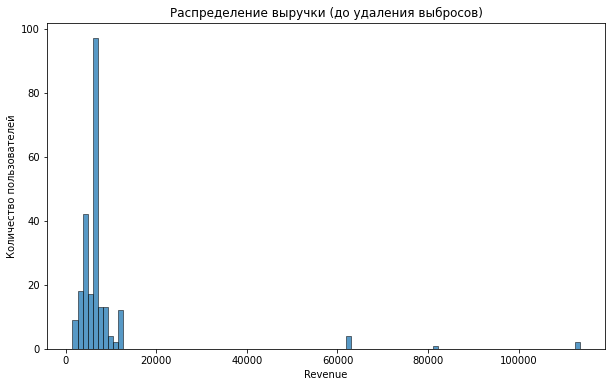

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(premium['revenue'], bins=100)

plt.title('Распределение выручки (до удаления выбросов)')
plt.xlabel('Revenue')
plt.ylabel('Количество пользователей')

plt.show()

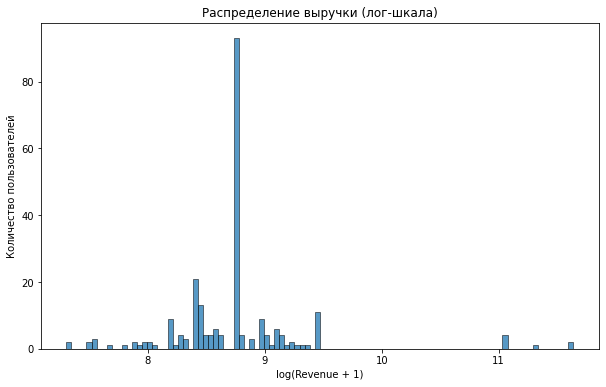

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(np.log1p(premium['revenue']), bins=100)

plt.title('Распределение выручки (лог-шкала)')
plt.xlabel('log(Revenue + 1)')
plt.ylabel('Количество пользователей')

plt.show()

##### 6.1 Находим выбросы

In [ ]:
### Для определения выбросов были проанализированы квантили распределения выручки:
    
premium['revenue'].quantile([0.95, 0.99, 0.999])

0.950     12597.00
0.990     75605.53
0.999    113477.00
Name: revenue, dtype: float64

В качестве порога для отсечения выбросов был выбран 99-й перцентиль.


Данный выбор обусловлен тем, что значения выше этого порога существенно выбиваются из общего распределения и могут искажать


средние метрики (ARPU/ARPPU). При этом отсекается менее 1% наблюдений, что позволяет сохранить репрезентативность выборки.

.


Также были рассмотрены альтернативные пороги (95-й и 99.9-й перцентили), однако 99-й перцентиль оказался оптимальным балансом


между удалением экстремальных значений и сохранением объема данных.

In [ ]:
q99 = premium['revenue'].quantile(0.99)

In [ ]:
premium_no_outliers = premium[premium['revenue'] <= q99]

###### 6.2 Пересчитываем

In [ ]:
user_revenue_no = (premium_no_outliers.groupby(['group','uid'])['revenue'].sum().reset_index())

##### 6.3 Повтор bootstrap

In [ ]:
# ARPU после удаления выбросов

test_rev_no = user_revenue_no[user_revenue_no['group']=='test']['revenue']

In [ ]:
c1_rev_no = user_revenue_no[user_revenue_no['group']=='control_1']['revenue']

In [ ]:
bootstrap_diff(test_rev_no, c1_rev_no)

array([-1737.44120974,  3560.35861815])

Интервал содержит 0. После удаления выбросов различия в ARPU перестают быть статистически значимыми.

In [ ]:
# ARPPU после удаления выбросов

test_rev_pay_no = user_revenue_no[(user_revenue_no['group']=='test') & (user_revenue_no['revenue'] > 0)]['revenue']

In [ ]:
c1_rev_pay_no = user_revenue_no[(user_revenue_no['group']=='control_1') & (user_revenue_no['revenue'] > 0)]['revenue']

In [ ]:
bootstrap_diff(test_rev_pay_no, c1_rev_pay_no)

array([-1484.03822228,  3427.76445168])

Bootstrap-интервал интерпретируем через ноль: если 0 входит в доверительный интервал разницы,
    
то нельзя отвергнуть гипотезу об отсутствии различий.


Для ARPU 0 входит в интервал, следовательно статистически значимых различий не выявлено.

Для ARPPU доверительный интервал также включает 0, что говорит об отсутствии статистически значимых различий в ARPPU

после удаления выбросов.

Это указывает на то, что ранее наблюдаемый эффект роста ARPPU в тестовой группе был обусловлен экстремальными значениями

и не является устойчивым.

### 7.Выводы

В результате A/B-теста было выявлено:

- Конверсия в тестовой группе статистически значимо ниже, чем в контрольных, что указывает на негативное влияние повышения цены на вероятность покупки.


- Изначально наблюдался рост ARPPU в тестовой группе, однако после удаления выбросов различия перестали быть статистически

значимыми. Это свидетельствует о том, что эффект был обусловлен экстремальными значениями и не является устойчивым.


- ARPU (ключевая бизнес-метрика) не показала статистически значимых различий между группами как до, так и после удаления выбросов.

Таким образом, эксперимент нельзя признать успешным: повышение цены привело к снижению конверсии, при этом устойчивого роста выручки на пользователя не наблюдается.


Рекомендуется дополнительно протестировать другие уровни цены или сегментировать пользователей для поиска оптимального баланса между конверсией и выручкой.